In [ ]:
import torch
import torchvision
from torchvision.datasets import MNIST

In [ ]:
dataset = MNIST(root="/data/", download=True)

In [ ]:
len(dataset)

60000

In [ ]:
test_dataset = MNIST(root='data/', train=False, download=True)
len(test_dataset)

10000

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

Label: 5


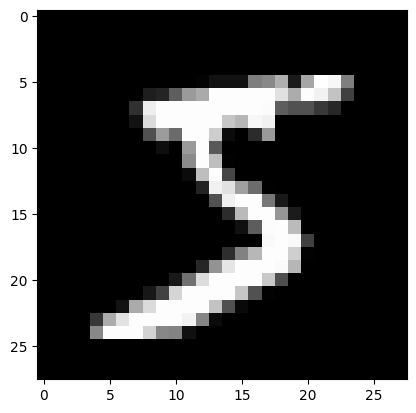

In [ ]:
image, label = dataset[0]
plt.imshow(image, cmap='gray')
print('Label:', label)

Label: 0


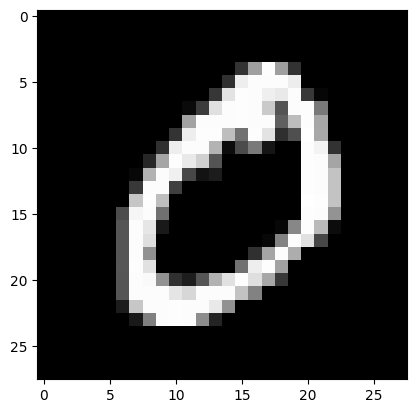

In [ ]:
image, label = dataset[1]
plt.imshow(image, cmap='gray')
print('Label:', label)

In [ ]:
import torchvision.transforms as transforms
dataset = MNIST(root='data/',
                train=True,
                transform=transforms.ToTensor())

In [ ]:
img_tensor, label = dataset[0]
print(img_tensor.shape, label)

torch.Size([1, 28, 28]) 5


In [ ]:
print(img_tensor[:,10:15,10:15])
print(torch.max(img_tensor), torch.min(img_tensor))

tensor([[[0.0039, 0.6039, 0.9922, 0.3529, 0.0000],
         [0.0000, 0.5451, 0.9922, 0.7451, 0.0078],
         [0.0000, 0.0431, 0.7451, 0.9922, 0.2745],
         [0.0000, 0.0000, 0.1373, 0.9451, 0.8824],
         [0.0000, 0.0000, 0.0000, 0.3176, 0.9412]]])
tensor(1.) tensor(0.)


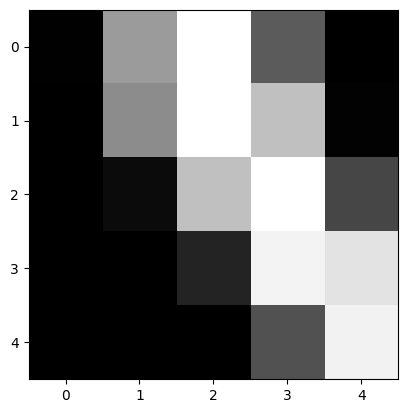

In [ ]:
plt.imshow(img_tensor[0,10:15,10:15], cmap='gray')

In [ ]:
from torch.utils.data import random_split

train_ds, val_ds = random_split(dataset, [50000, 10000])
len(train_ds), len(val_ds)

(50000, 10000)

In [ ]:
from torch.utils.data import DataLoader

batch_size = 128

train_loader = DataLoader(train_ds, batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size)

In [ ]:
import torch.nn as nn

In [ ]:
input_size = 28*28
num_classes = 10
model = nn.Linear(input_size, num_classes)

In [ ]:
print(model.weight.shape)
print(model.bias.shape)

torch.Size([10, 784])
torch.Size([10])


In [ ]:
model.weight

Parameter containing:
tensor([[-0.0010,  0.0203,  0.0006,  ..., -0.0149, -0.0086,  0.0100],
        [ 0.0240,  0.0056,  0.0056,  ...,  0.0216,  0.0159, -0.0097],
        [ 0.0280, -0.0133, -0.0313,  ...,  0.0037,  0.0335,  0.0163],
        ...,
        [ 0.0286, -0.0180,  0.0283,  ...,  0.0258, -0.0049, -0.0180],
        [ 0.0228,  0.0319,  0.0078,  ...,  0.0144,  0.0036, -0.0264],
        [-0.0127, -0.0118,  0.0181,  ...,  0.0179,  0.0127, -0.0301]],
       requires_grad=True)

In [ ]:
model.bias

Parameter containing:
tensor([-0.0278,  0.0248,  0.0281, -0.0176, -0.0107,  0.0177, -0.0155,  0.0353,
         0.0115,  0.0168], requires_grad=True)

In [ ]:
class MnistModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(input_size, num_classes)

    def forward(self, xb):
        xb = xb.reshape(-1, 784)
        out = self.linear(xb)
        return out

model = MnistModel()

In [ ]:
list(model.parameters())

[Parameter containing:
 tensor([[-0.0312, -0.0075,  0.0052,  ...,  0.0130,  0.0230,  0.0243],
         [-0.0308,  0.0050, -0.0088,  ..., -0.0183, -0.0269, -0.0357],
         [ 0.0059, -0.0205,  0.0018,  ..., -0.0080,  0.0238,  0.0233],
         ...,
         [ 0.0093,  0.0060, -0.0211,  ...,  0.0014,  0.0148, -0.0223],
         [ 0.0154, -0.0322, -0.0050,  ...,  0.0318, -0.0134,  0.0184],
         [ 0.0076, -0.0357, -0.0031,  ...,  0.0302, -0.0196,  0.0323]],
        requires_grad=True),
 Parameter containing:
 tensor([ 0.0320,  0.0317, -0.0202, -0.0313, -0.0264, -0.0069, -0.0102, -0.0322,
         -0.0272, -0.0163], requires_grad=True)]

In [ ]:
import torch.nn.functional as F

In [ ]:
for images, labels in train_loader:
    outputs = model(images)
    break
probs = F.softmax(outputs, dim=1)
print(probs[:3].data)

tensor([[0.0861, 0.1349, 0.1063, 0.0879, 0.1119, 0.0776, 0.1248, 0.0849, 0.0879,
         0.0977],
        [0.0901, 0.1378, 0.0943, 0.0792, 0.1119, 0.0689, 0.1236, 0.1035, 0.0988,
         0.0920],
        [0.0949, 0.1341, 0.0932, 0.0898, 0.0901, 0.0964, 0.1226, 0.0917, 0.0913,
         0.0959]])


In [ ]:
print(torch.sum(probs[:3]).item())

3.0


In [ ]:
max_probs, preds = torch.max(probs, dim=1)
print(preds)
print(max_probs)

tensor([1, 1, 1, 1, 3, 4, 1, 1, 1, 0, 1, 1, 1, 1, 4, 6, 6, 0, 4, 6, 6, 1, 0, 1,
        4, 1, 4, 6, 1, 1, 6, 1, 1, 1, 1, 3, 4, 1, 6, 1, 1, 1, 1, 1, 1, 6, 1, 6,
        6, 3, 1, 6, 1, 6, 4, 9, 6, 6, 1, 2, 1, 1, 5, 1, 1, 1, 6, 1, 1, 7, 6, 5,
        1, 6, 1, 1, 0, 1, 6, 1, 1, 6, 1, 6, 1, 1, 1, 1, 1, 1, 6, 6, 1, 1, 1, 1,
        3, 1, 5, 1, 1, 1, 6, 4, 1, 1, 1, 1, 1, 1, 1, 4, 1, 6, 1, 6, 1, 6, 1, 1,
        1, 1, 6, 1, 6, 3, 6, 6])
tensor([0.1349, 0.1378, 0.1341, 0.1351, 0.1249, 0.1332, 0.1318, 0.1439, 0.1456,
        0.1331, 0.1470, 0.1128, 0.1247, 0.1286, 0.1322, 0.1349, 0.1257, 0.1368,
        0.1338, 0.1165, 0.1198, 0.1486, 0.1084, 0.1229, 0.1351, 0.1150, 0.1273,
        0.1216, 0.1316, 0.1469, 0.1262, 0.1461, 0.1602, 0.1232, 0.1367, 0.1278,
        0.1209, 0.1306, 0.1150, 0.1714, 0.1252, 0.1438, 0.1482, 0.1317, 0.1733,
        0.1444, 0.1281, 0.1187, 0.1287, 0.1106, 0.1335, 0.1189, 0.1311, 0.1270,
        0.1135, 0.1293, 0.1557, 0.1210, 0.1248, 0.1227, 0.1510, 0.1597, 0.1172,
       

In [ ]:
labels

tensor([1, 8, 9, 1, 0, 8, 0, 2, 9, 5, 3, 4, 0, 2, 9, 8, 0, 3, 8, 4, 5, 9, 1, 6,
        3, 6, 8, 2, 9, 1, 0, 6, 2, 4, 6, 3, 2, 0, 1, 4, 1, 9, 0, 0, 9, 5, 7, 0,
        0, 2, 0, 9, 8, 8, 3, 7, 2, 3, 4, 4, 6, 1, 4, 8, 4, 3, 6, 2, 6, 7, 1, 5,
        2, 1, 2, 8, 1, 5, 7, 4, 3, 3, 3, 5, 3, 5, 6, 0, 8, 8, 6, 2, 0, 5, 5, 4,
        6, 9, 0, 5, 1, 8, 1, 2, 9, 4, 3, 7, 5, 5, 2, 9, 4, 3, 7, 1, 8, 6, 9, 6,
        8, 0, 0, 9, 7, 2, 8, 1])

In [ ]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

In [ ]:
accuracy(outputs, labels)

tensor(0.0938)

In [ ]:
loss_fn = F.cross_entropy
loss = loss_fn(outputs, labels)
print(loss)

tensor(2.3102, grad_fn=<NllLossBackward0>)


In [ ]:
def evaluate(model, val_loader):
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

In [ ]:
import torch
def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.SGD):
    optimizer = opt_func(model.parameters(), lr)
    ans = []
    for epoch in range(epochs):
        for batch in train_loader:
            loss = model.training_step(batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        result = evaluate(model, val_loader)
        model.epoch_end(epoch, result)
        ans.append(result)
    return ans

In [ ]:
import torch.nn as nn
input_size = 28*28
num_classes = 10
class MnistModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(input_size, num_classes)

    def forward(self, xb):
        xb = xb.reshape(-1, 784)
        out = self.linear(xb)
        return out

    def training_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        return loss

    def validation_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        acc = accuracy(out, labels)
        return {'val_loss': loss, 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
       print("Epoch [" + str(epoch) + "], val_loss: " + str(round(result['val_loss'], 4)) + ", val_acc: " + str(round(result['val_acc'], 4)))

model = MnistModel()

In [ ]:
ans1 = fit(25, 0.04, model, train_loader, val_loader)

Epoch [0], val_loss: 0.5222, val_acc: 0.8725
Epoch [1], val_loss: 0.434, val_acc: 0.8871
Epoch [2], val_loss: 0.3986, val_acc: 0.8933
Epoch [3], val_loss: 0.3784, val_acc: 0.8963
Epoch [4], val_loss: 0.3648, val_acc: 0.899
Epoch [5], val_loss: 0.3539, val_acc: 0.9022
Epoch [6], val_loss: 0.3465, val_acc: 0.9025
Epoch [7], val_loss: 0.3406, val_acc: 0.9047
Epoch [8], val_loss: 0.3353, val_acc: 0.9057
Epoch [9], val_loss: 0.3308, val_acc: 0.9066
Epoch [10], val_loss: 0.3276, val_acc: 0.9077
Epoch [11], val_loss: 0.3247, val_acc: 0.9088
Epoch [12], val_loss: 0.3215, val_acc: 0.9106
Epoch [13], val_loss: 0.3195, val_acc: 0.9119
Epoch [14], val_loss: 0.3177, val_acc: 0.9122
Epoch [15], val_loss: 0.3151, val_acc: 0.9126
Epoch [16], val_loss: 0.3134, val_acc: 0.914
Epoch [17], val_loss: 0.3118, val_acc: 0.9138
Epoch [18], val_loss: 0.3099, val_acc: 0.9148
Epoch [19], val_loss: 0.3088, val_acc: 0.9145
Epoch [20], val_loss: 0.3075, val_acc: 0.9155
Epoch [21], val_loss: 0.3069, val_acc: 0.9164
E